# Análisis de datos, procesamiento de datos y modelos de predicción

In [ ]:
import pandas as pd

df = pd.read_csv('/content/Real estate.csv')

df.head()


,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


Visualizamos el dataset y sus respectivas columnas


In [ ]:
df.info()

df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,207.500000,2013.148971,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,119.655756,0.281967,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,1.000000,2012.667000,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,104.250000,2012.917000,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,207.500000,2013.167000,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,310.750000,2013.417000,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,414.000000,2013.583000,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


CAMBIAMOS EL NOMBRE DE LAS COLUMNAS

In [ ]:
df.rename(columns={
    "X1 transaction date": "Fecha_Transaccion",
    "X2 house age": "Edad_Casa",
    "X3 distance to the nearest MRT station": "Distancia_MRT",
    "X4 number of convenience stores": "Tiendas_Cercanas",
    "X5 latitude": "Latitud",
    "X6 longitude": "Longitud",
    "Y house price of unit area": "Precio_Unitario"
}, inplace=True)

df.head()


,No,Fecha_Transaccion,Edad_Casa,Distancia_MRT,Tiendas_Cercanas,Latitud,Longitud,Precio_Unitario
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


PERFILADO DE DATOS

In [ ]:
!pip install ydata-profiling

from ydata_profiling import ProfileReport

profile = ProfileReport(df, explorative=True)

profile.to_notebook_iframe()


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

LIMPIEZA DEL DATASET

In [ ]:
print(df.isnull().sum())

print(f"Filas duplicadas: {df.duplicated().sum()}")


No                   0
Fecha_Transaccion    0
Edad_Casa            0
Distancia_MRT        0
Tiendas_Cercanas     0
Latitud              0
Longitud             0
Precio_Unitario      0
dtype: int64
Filas duplicadas: 0


In [ ]:
df.dropna(inplace=True)

df.drop_duplicates(inplace=True)

print(df.isnull().sum())
print(f"Filas duplicadas: {df.duplicated().sum()}")


No                   0
Fecha_Transaccion    0
Edad_Casa            0
Distancia_MRT        0
Tiendas_Cercanas     0
Latitud              0
Longitud             0
Precio_Unitario      0
dtype: int64
Filas duplicadas: 0


MATRIZ DE CORRELACIÓN

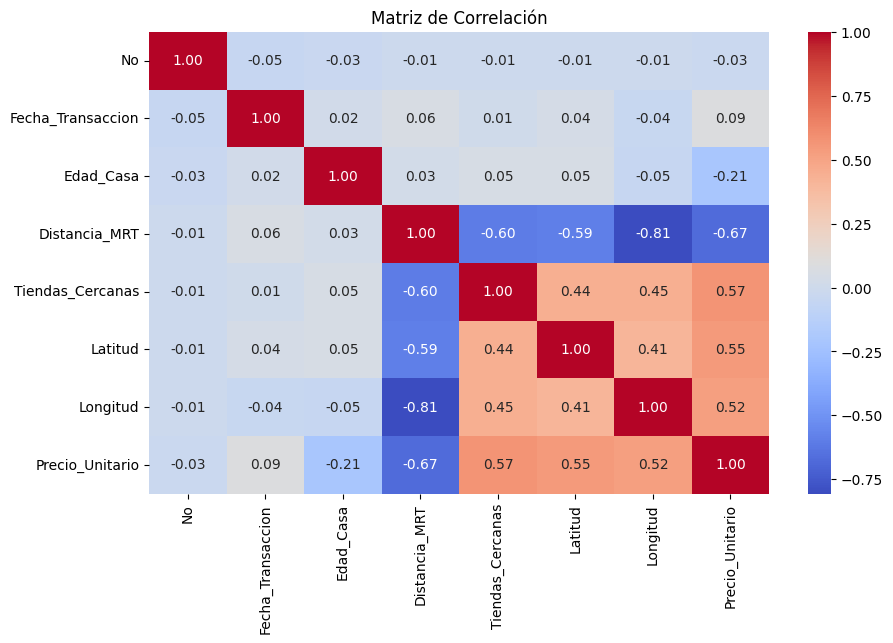

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()


VISUALIZAMOS EL DATASET

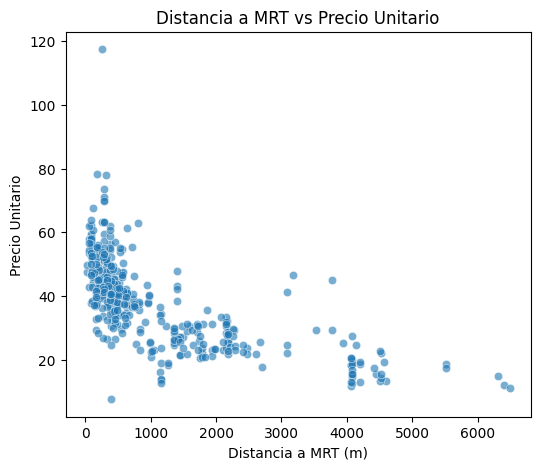

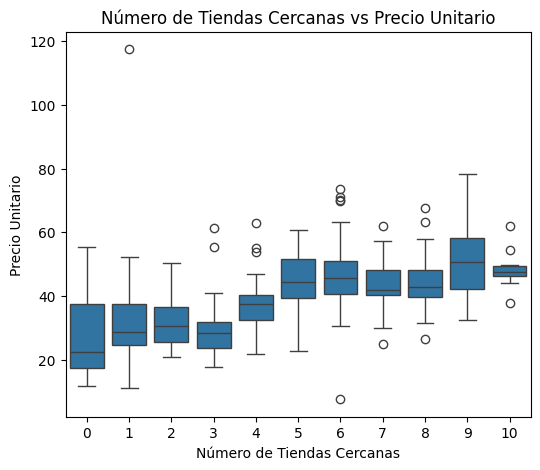

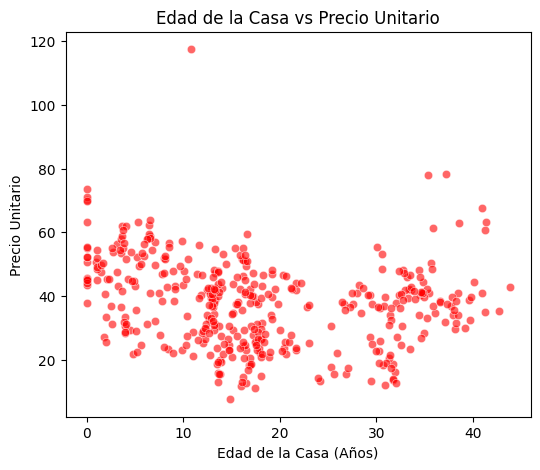

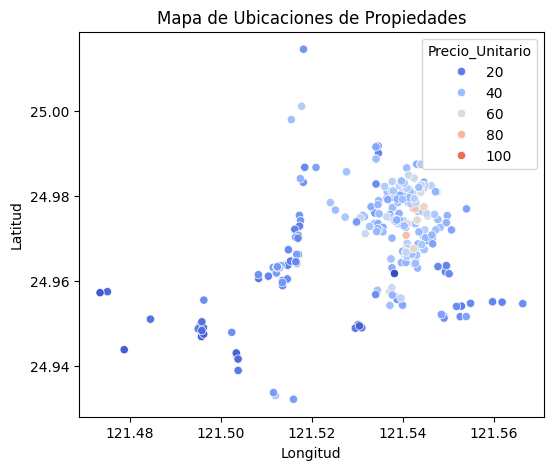

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.scatterplot(x=df["Distancia_MRT"], y=df["Precio_Unitario"], alpha=0.6)
plt.title("Distancia a MRT vs Precio Unitario")
plt.xlabel("Distancia a MRT (m)")
plt.ylabel("Precio Unitario")
plt.show()

plt.figure(figsize=(6, 5))
sns.boxplot(x=df["Tiendas_Cercanas"], y=df["Precio_Unitario"])
plt.title("Número de Tiendas Cercanas vs Precio Unitario")
plt.xlabel("Número de Tiendas Cercanas")
plt.ylabel("Precio Unitario")
plt.show()

plt.figure(figsize=(6, 5))
sns.scatterplot(x=df["Edad_Casa"], y=df["Precio_Unitario"], alpha=0.6, color="red")
plt.title("Edad de la Casa vs Precio Unitario")
plt.xlabel("Edad de la Casa (Años)")
plt.ylabel("Precio Unitario")
plt.show()

plt.figure(figsize=(6, 5))
sns.scatterplot(x=df["Longitud"], y=df["Latitud"], hue=df["Precio_Unitario"], palette="coolwarm")
plt.title("Mapa de Ubicaciones de Propiedades")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.show()


CREAMOS UN MAPA INTERACTIVO

In [ ]:
import folium
from folium.plugins import MarkerCluster
import pandas as pd


mapa = folium.Map(location=[df["Latitud"].mean(), df["Longitud"].mean()], zoom_start=12)

marker_cluster = MarkerCluster().add_to(mapa)

for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row["Latitud"], row["Longitud"]],
        radius=5,
        color="red" if row["Precio_Unitario"] > df["Precio_Unitario"].median() else "blue",
        fill=True,
        fill_color="red" if row["Precio_Unitario"] > df["Precio_Unitario"].median() else "blue",
        fill_opacity=0.6,
        popup=f"Precio: {row['Precio_Unitario']}"
    ).add_to(marker_cluster)

mapa


MODELOS


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Precio_Unitario', axis=1)
y = df['Precio_Unitario']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


REGRESIÓN LINEAL

In [ ]:
from sklearn.linear_model import LinearRegression

modelo_rl = LinearRegression()
modelo_rl.fit(X_train, y_train)

y_pred_rl = modelo_rl.predict(X_test)


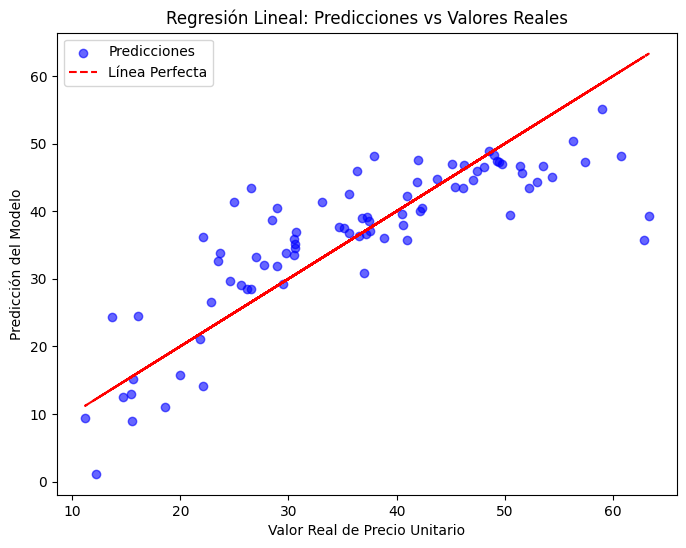

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rl, alpha=0.6, color="blue", label="Predicciones")
plt.plot(y_test, y_test, color="red", linestyle="dashed", label="Línea Perfecta")
plt.xlabel("Valor Real de Precio Unitario")
plt.ylabel("Predicción del Modelo")
plt.title("Regresión Lineal: Predicciones vs Valores Reales")
plt.legend()
plt.show()

ÁRBOL DE DECISIONES

In [ ]:
from sklearn.tree import DecisionTreeRegressor

modelo_ad = DecisionTreeRegressor(random_state=42)
modelo_ad.fit(X_train, y_train)

y_pred_ad = modelo_ad.predict(X_test)


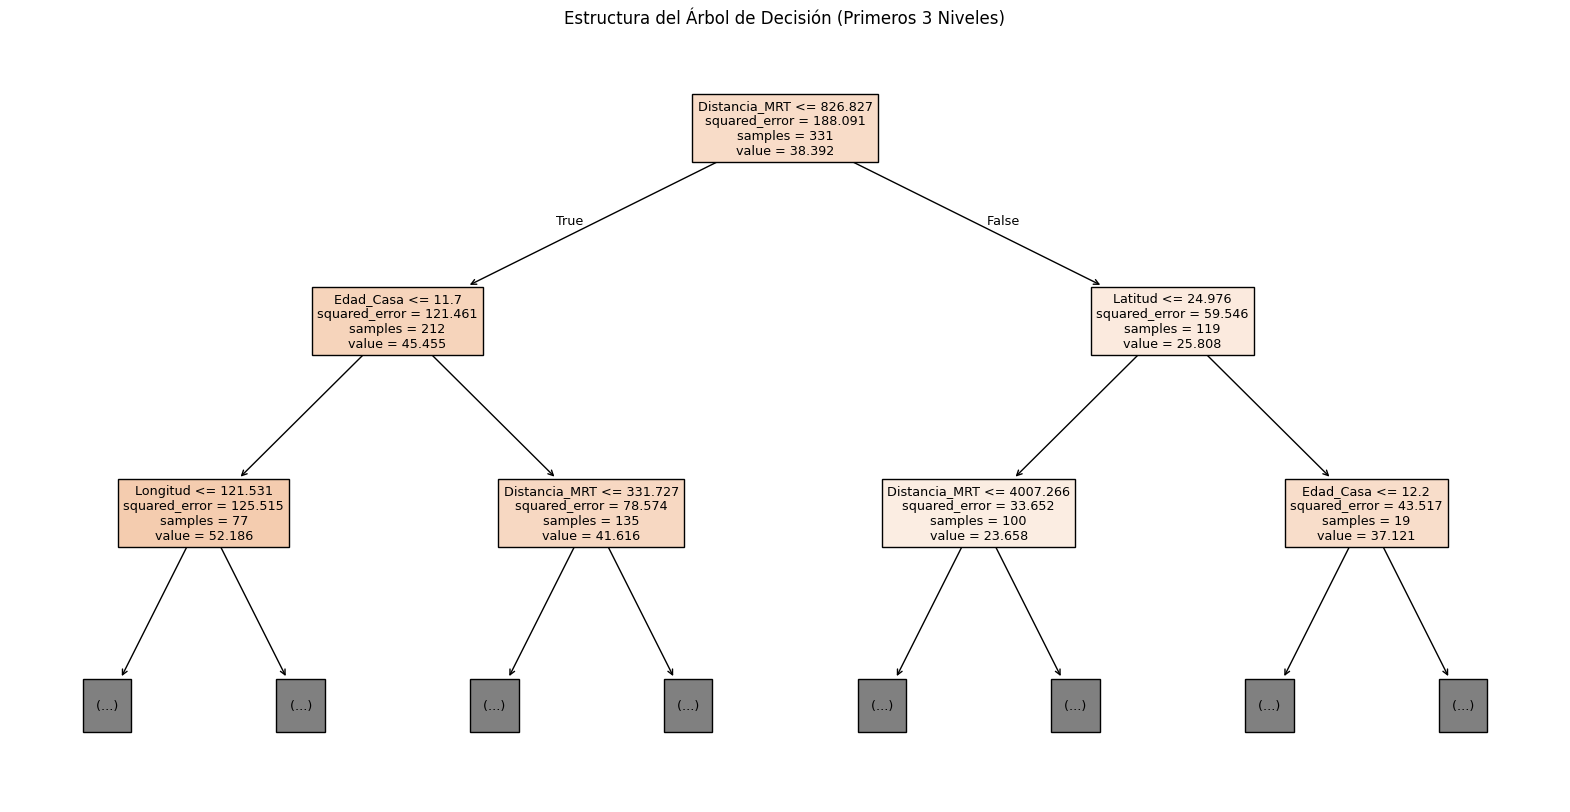

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(modelo_ad, filled=True, feature_names=X_train.columns, max_depth=2)
plt.title("Estructura del Árbol de Decisión (Primeros 3 Niveles)")
plt.show()

RESULTADOS

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

mae_rl = mean_absolute_error(y_test, y_pred_rl)
r2_rl = r2_score(y_test, y_pred_rl)

mae_ad = mean_absolute_error(y_test, y_pred_ad)
r2_ad = r2_score(y_test, y_pred_ad)

print(f'Regresión Lineal - MAE: {mae_rl}, R²: {r2_rl}')
print(f'Árbol de Decisión - MAE: {mae_ad}, R²: {r2_ad}')


Regresión Lineal - MAE: 5.418035098629173, R²: 0.6745228670350882
Árbol de Decisión - MAE: 5.360240963855421, R²: 0.6787466883184802


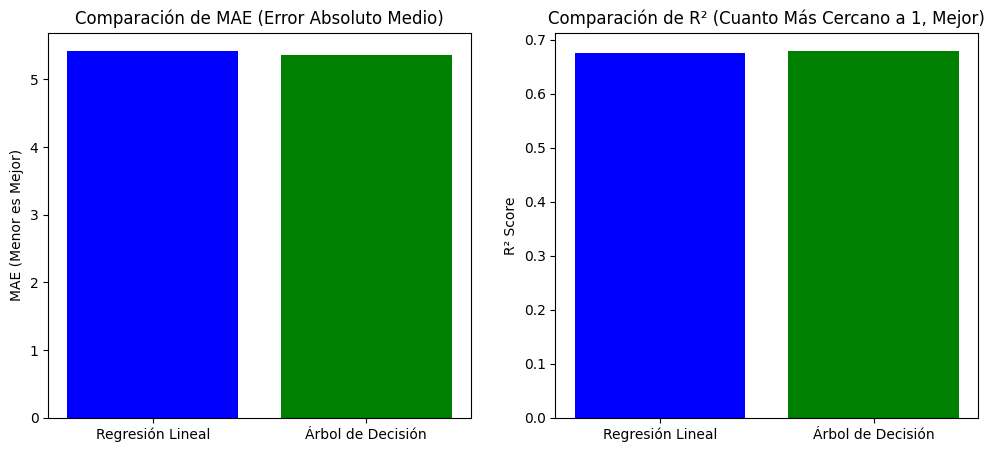

In [ ]:
import matplotlib.pyplot as plt

modelos = ["Regresión Lineal", "Árbol de Decisión"]
mae = [mae_rl, mae_ad]
r2 = [r2_rl, r2_ad]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(modelos, mae, color=["blue", "green"])
axes[0].set_title("Comparación de MAE (Error Absoluto Medio)")
axes[0].set_ylabel("MAE (Menor es Mejor)")

axes[1].bar(modelos, r2, color=["blue", "green"])
axes[1].set_title("Comparación de R² (Cuanto Más Cercano a 1, Mejor)")
axes[1].set_ylabel("R² Score")

plt.show()


In [ ]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("R² Score:", r2_score(y_test, y_pred_rf))


MAE: 3.8668554216867457
R² Score: 0.81009013191504


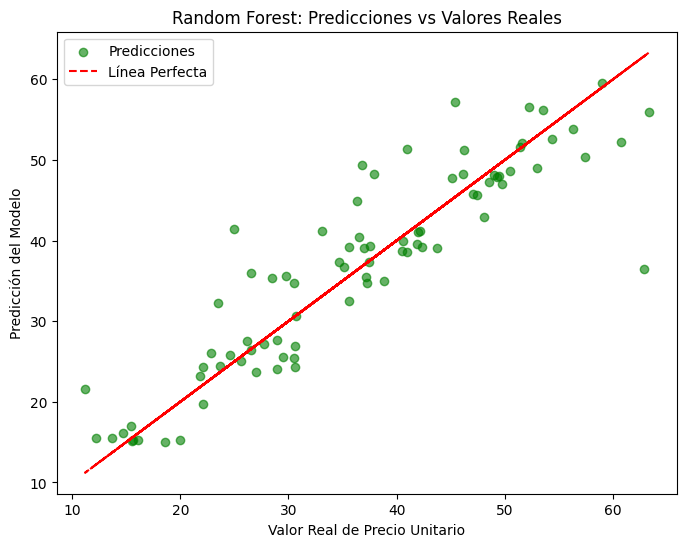

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, model_rf.predict(X_test), alpha=0.6, color="green", label="Predicciones")
plt.plot(y_test, y_test, color="red", linestyle="dashed", label="Línea Perfecta")
plt.xlabel("Valor Real de Precio Unitario")
plt.ylabel("Predicción del Modelo")
plt.title("Random Forest: Predicciones vs Valores Reales")
plt.legend()
plt.show()

In [ ]:
import joblib
import numpy as np

test_input = np.array([2012.917, 32, 1500, 8, 25.03, 121.54, 3.2]).reshape(1, -1)
print(f"Predicción del modelo: {model.predict(test_input)}")


Predicción del modelo: [52.785]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


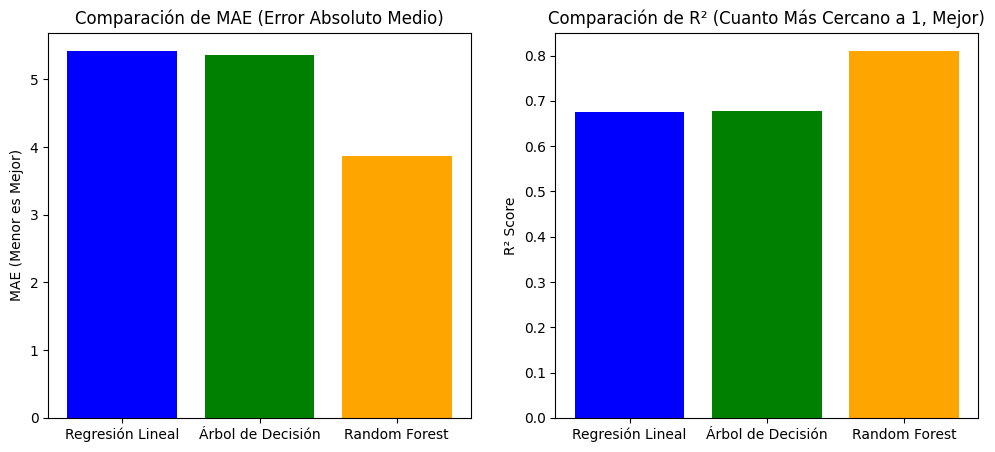

In [ ]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

modelos = ["Regresión Lineal", "Árbol de Decisión", "Random Forest"]
mae = [mae_rl, mae_ad, mae_rf]
r2 = [r2_rl, r2_ad, r2_rf]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(modelos, mae, color=["blue", "green", "orange"])
axes[0].set_title("Comparación de MAE (Error Absoluto Medio)")
axes[0].set_ylabel("MAE (Menor es Mejor)")

axes[1].bar(modelos, r2, color=["blue", "green", "orange"])
axes[1].set_title("Comparación de R² (Cuanto Más Cercano a 1, Mejor)")
axes[1].set_ylabel("R² Score")

plt.show()


In [ ]:
import joblib

joblib.dump(model_rf, "modelo_rf.pkl")

from google.colab import files
files.download("modelo_rf.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>